# IT2011 — 2026-Y2-S1-KU-02
# Member 5: Chandrasooriya J.T. (IT25100146)
## Technique: Feature Selection

**Why it's needed for this dataset:** Treating each of the 784 pixels as an individual feature, pixels near
the image border are almost always 0 across the entire dataset, since digits are centered in the canvas.
Near-constant features carry no discriminative information and can be removed before modeling.


## Setup

This notebook is self-contained: it loads MNIST itself and reproduces any minimal prerequisite steps from a
teammate's earlier pipeline stage (noted where relevant).


In [ ]:

# Install TensorFlow if it is not already available in the current Python environment.
# This ensures that the required TensorFlow/Keras libraries are available when the notebook
# is shared and executed on another computer or in a different Python environment.
%pip install tensorflow

In [ ]:
#Import essential libraries for data handling, visualization, and suppressing warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

#Ignore non-critical warnings for cleaner output
warnings.filterwarnings('ignore')

#Import MNIST handwritten digit dataset from Keras
from tensorflow.keras.datasets import mnist

#Set plot style and resolution for better visuals
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

#Fix random seed so results are consistent across runs
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

#Load MNIST dataset into training and test splits
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("Training images:", X_train.shape, "| Training labels:", y_train.shape)
print("Test images:    ", X_test.shape,  "| Test labels:    ", y_test.shape)


*Prerequisite (reproducing normalization minimally, so this notebook is self-contained):*


In [ ]:
#Normalize pixel values to [0,1] range for better model convergence
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

#Flatten each 28×28 image into a 784‑dimensional vector
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)
print("Original feature count (pixels):", X_train_flat.shape[1])


In [ ]:
#Calculate variance of each pixel across the dataset
from sklearn.feature_selection import VarianceThreshold

pixel_variance = X_train_flat.var(axis=0)

#Drop near‑constant pixels (mostly borders) to reduce dimensionality
selector = VarianceThreshold(threshold=0.01)
X_train_selected = selector.fit_transform(X_train_flat)
X_test_selected = selector.transform(X_test_flat)

#Check how many pixels were retained vs. removed
selected_mask = selector.get_support()
print("Selected feature count after thresholding:", X_train_selected.shape[1])
print("Removed (near-constant / low-variance) pixels:", int((~selected_mask).sum()))


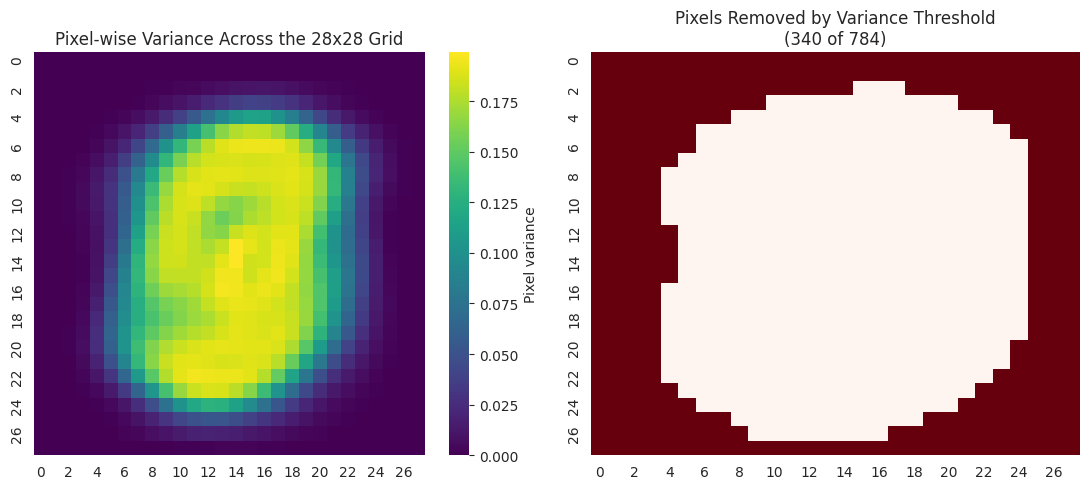

In [ ]:
#Visualize variance distribution and highlight removed pixels
import os

variance_grid = pixel_variance.reshape(28, 28)
removed_grid = (~selected_mask).reshape(28, 28)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

sns.heatmap(variance_grid, cmap='viridis', ax=axes[0], cbar_kws={'label': 'Pixel variance'})
axes[0].set_title("Pixel-wise Variance Across the 28x28 Grid")

sns.heatmap(removed_grid, cmap='Reds', ax=axes[1], cbar=False)
axes[1].set_title(f"Pixels Removed by Variance Threshold\n({int((~selected_mask).sum())} of 784)")

plt.tight_layout()

# Create the directory if it does not exist
output_dir = '../results/eda_visualizations/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, '05_feature_selection.png'), bbox_inches='tight')
plt.show()

**Interpretation:** The variance heatmap lights up in a roughly digit-shaped region in the center of the
canvas, while the border/corner pixels are dark (near-zero variance) — confirming they are almost always
background across the whole dataset. The removed-pixel map matches this: a border-and-corner frame of
low-information pixels is dropped, cutting the feature count while keeping every pixel that actually varies
across digits.
